In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Histogram Plot

In [2]:
def generate_histogram(image):
    # Calculate the histogram of the grayscale image
    histogram = cv2.calcHist(
        [image],      # Input image
        [0],          # Channel 0 for grayscale image
        None,         # No mask → use the entire image else use mask area: [100:300, 100:300]
        [256],        # Number of histogram bins
        [0, 256])     # Intensity range  #  [0, 256) range covering intensity values 0–255

    return histogram

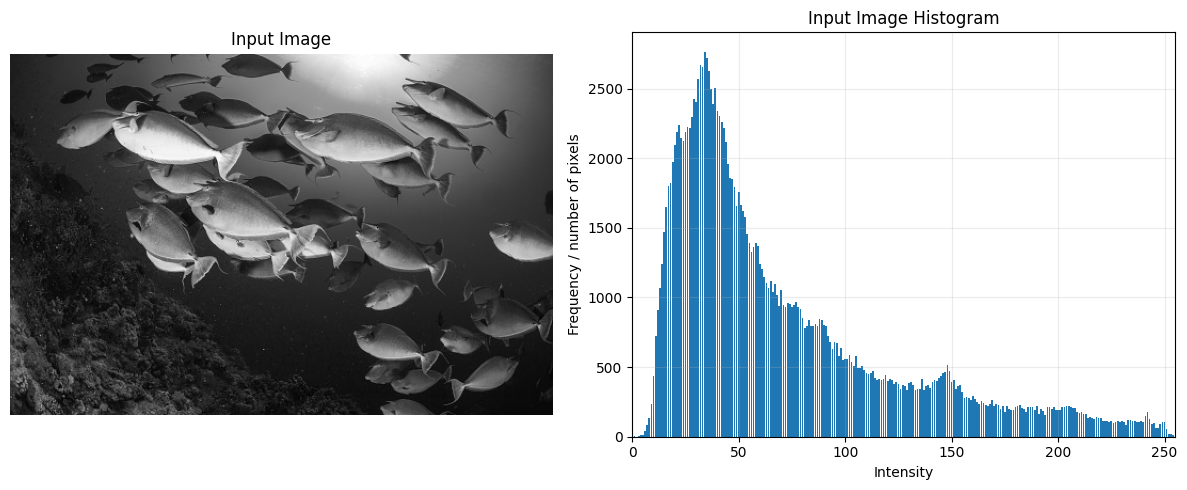

In [3]:
# Load the input image
input_path = "/content/drive/MyDrive/DSIP/fish.jpg"
input_image = cv2.imread(input_path)

# Convert the image to grayscale
gray_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)

# Generate the histogram of the grayscale image
input_hist = generate_histogram(gray_image)

# Create intensity values from 0 to 255
intensity = np.arange(256)

# Display the image and histogram side by side
plt.figure(figsize=(12, 5))

# Display the grayscale image
plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Input Image")
plt.axis("off")

# Display the histogram
plt.subplot(1, 2, 2)
plt.bar(intensity, input_hist)
plt.title("Input Image Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency / number of pixels")
plt.xlim([0, 255])
plt.grid(alpha=0.25)

# Adjust spacing
plt.tight_layout()

# Display the result
plt.show()

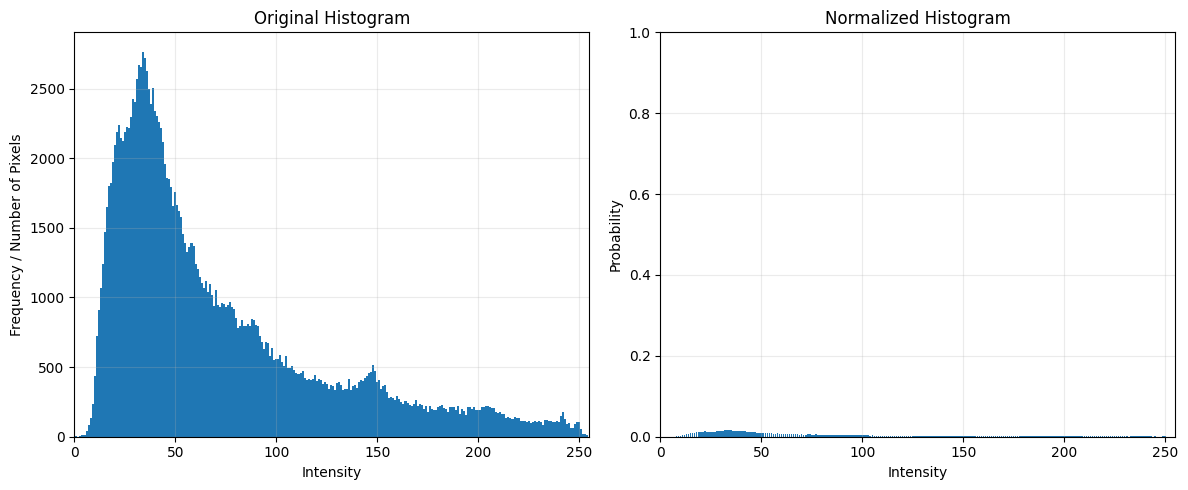

In [5]:
# Calculate the total number of pixels
total_pixels = gray_image.size

# Normalize the histogram
normalized_hist = input_hist / total_pixels

# Display original and normalized histograms
plt.figure(figsize=(12, 5))

# Original histogram
plt.subplot(1, 2, 1)
plt.bar(intensity, input_hist, width=1)
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency / Number of Pixels")
plt.xlim([0, 255])
plt.grid(alpha=0.25)

# Normalized histogram
plt.subplot(1, 2, 2)
plt.bar(intensity, normalized_hist)
plt.title("Normalized Histogram")
plt.xlabel("Intensity")
plt.ylabel("Probability")
plt.xlim([0, 255])
plt.ylim([0, 1])
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Histogram Equalization

In [7]:
def perform_histogram_equalization(image):
  # Convert image to grayscale
  gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

  # Apply histogram equalization
  equalized_image = cv2.equalizeHist(gray_image)
  return equalized_image

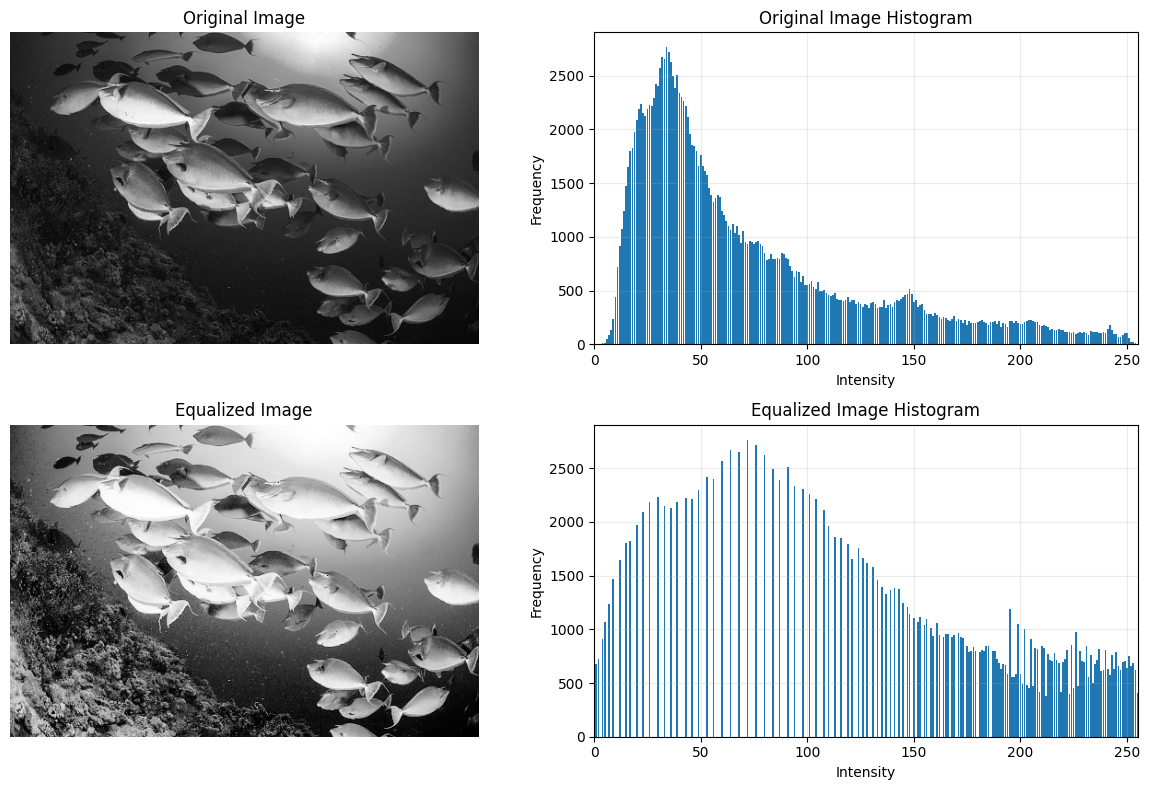

In [8]:
# Perform histogram equalization
equalized_image = perform_histogram_equalization(input_image)

# Generate histograms
original_hist = generate_histogram(gray_image)
equalized_hist = generate_histogram(equalized_image)

# Create intensity values from 0 to 255
intensity = np.arange(256)

# Display everything in a 2 × 2 layout
plt.figure(figsize=(12, 8))

# 1. Original Image
plt.subplot(2, 2, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# 2. Original Histogram
plt.subplot(2, 2, 2)
plt.bar(intensity, original_hist)
plt.title("Original Image Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 255])
plt.grid(alpha=0.25)

# 3. Equalized Image
plt.subplot(2, 2, 3)
plt.imshow(equalized_image, cmap="gray")
plt.title("Equalized Image")
plt.axis("off")

# 4. Equalized Histogram
plt.subplot(2, 2, 4)
plt.bar(intensity, equalized_hist)
plt.title("Equalized Image Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 255])
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Histogram Matching

In [9]:
# Load the input image
input_path = "/content/drive/MyDrive/DSIP/fish.jpg"
input_image = cv2.imread(input_path)

# Convert the image to grayscale
gray_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)

# Load the reference image
reference_path = "/content/drive/MyDrive/DSIP/clouds.jpg"
reference_image = cv2.imread(reference_path)

# Convert the reference image to grayscale
gray_reference = cv2.cvtColor(reference_image, cv2.COLOR_BGR2GRAY)


In [10]:
from skimage.exposure import match_histograms

In [11]:
# Perform histogram matching
matched_image = match_histograms(gray_image,gray_reference)

In [12]:
matched_image.dtype

dtype('float64')

In [13]:
# Convert the matched image to 8-bit format
matched_image = np.uint8(matched_image)

In [14]:
matched_image.dtype

dtype('uint8')

In [15]:
# Generate the histogram of the original image
original_hist = generate_histogram(gray_image)

# Generate the histogram of the reference image
reference_hist = generate_histogram(gray_reference)

# Generate the histogram of the matched image
matched_hist = generate_histogram(matched_image)

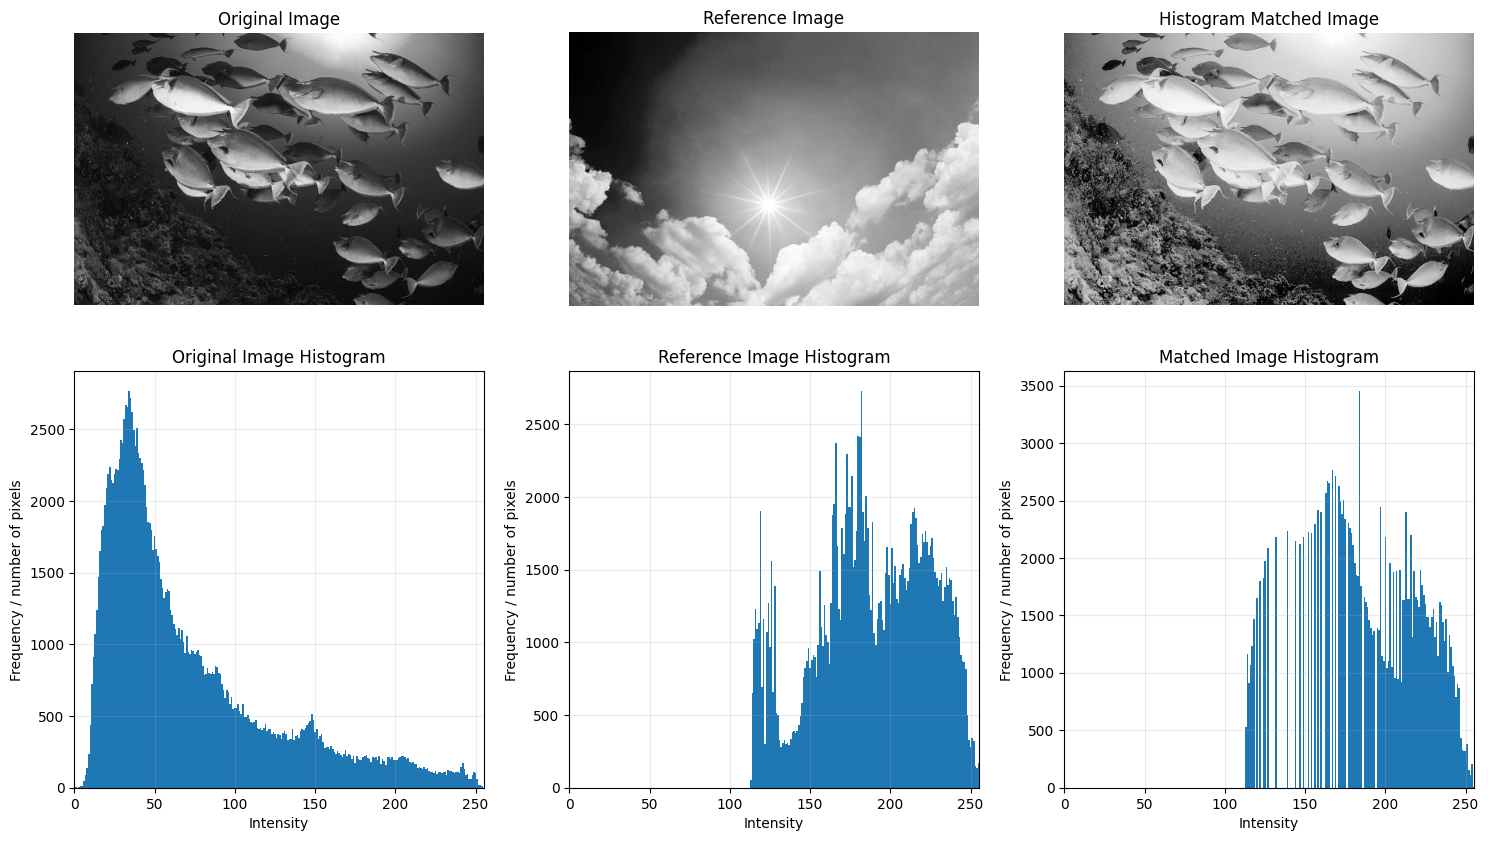

In [16]:
# Create intensity values from 0 to 255
intensity = np.arange(256)

# Display images and histograms
plt.figure(figsize=(15, 9))

# Display the original image
plt.subplot(2, 3, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Display the reference image
plt.subplot(2, 3, 2)
plt.imshow(gray_reference, cmap="gray")
plt.title("Reference Image")
plt.axis("off")

# Display the matched image
plt.subplot(2, 3, 3)
plt.imshow(matched_image, cmap="gray")
plt.title("Histogram Matched Image")
plt.axis("off")

# Display the original histogram
plt.subplot(2, 3, 4)
plt.bar(intensity, original_hist, width=1)
plt.title("Original Image Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency / number of pixels")
plt.xlim([0, 255])
plt.grid(alpha=0.25)

# Display the reference histogram
plt.subplot(2, 3, 5)
plt.bar(intensity, reference_hist, width=1)
plt.title("Reference Image Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency / number of pixels")
plt.xlim([0, 255])
plt.grid(alpha=0.25)

# Display the matched histogram
plt.subplot(2, 3, 6)
plt.bar(intensity, matched_hist, width=1)
plt.title("Matched Image Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency / number of pixels")
plt.xlim([0, 255])
plt.grid(alpha=0.25)

# Adjust spacing
plt.tight_layout()

# Display the results
plt.show()